# Kapitel 6 koduppgifter

### 7.

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       3
1         8.3014     37.86    -122.22       3
2         7.2574     37.85    -122.24       3
3         5.6431     37.85    -122.25       5
4         3.8462     37.85    -122.25       5


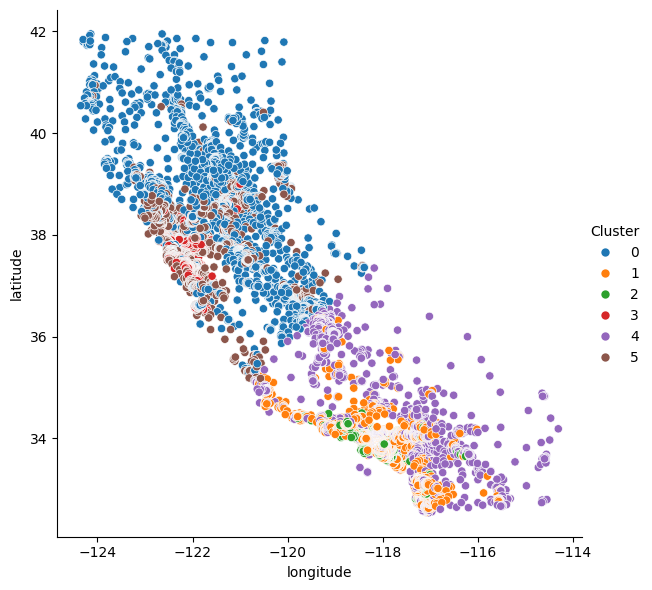

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
df = pd.read_csv("data/housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())
kmeans = KMeans(n_clusters=6)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")
print(X.head())
sns.relplot(x="longitude", y="latitude", hue="Cluster", data=X, height=6)


a) Vad gör koden?

Koden läser in data om bostadsområden i Kalifornien och tittar på tre saker för varje område: inkomst, latitud och longitud (var på kartan området ligger). Sedan delar den in områdena i 6 grupper (kluster), så att områden som ligger nära varandra och har liknande
inkomst hamnar i samma grupp. Till sist ritas en karta där varje grupp har en egen färg.

b) Vilken information hade jag velat ha, och hur hade jag gjort undersökningen?

- Ålder, familjesituation och om man äger eller hyr sin bostad
- Vilken bostadstyp och storlek man vill ha, och vilken prisnivå
- Vad som är viktigt i ett område, till exempel skolor, pendling, natur eller nöjesliv
- Hur man vill bli kontaktad: mejl, sms, telefon eller sociala medier
- Om man planerar att flytta snart

Så hade jag gjort undersökningen:
- Ett slumpmässigt urval av personer från varje kluster, så att alla grupper är med
- En kort webbenkät med mest flervalsfrågor, gärna kompletterad med några intervjuer för djupare svar
- Samma frågor till alla, så att det går att jämföra grupperna

c) Hur kan det vara användbart för ett företag?

- Rätt reklam till rätt grupp: till exempel lyxbostäder till höginkomstområden och prisvärda lägenheter till andra omr
- Rätt kanal: man når varje grupp där de faktiskt finns.
- Bättre beslut om var man ska bygga eller öppna kontor.
- Sparade pengar: mindre reklam som når fel personer.

d) Hur många kluster är bra?

Ett enkelt sätt är armbågsmetoden. Man provar olika antal kluster och ser när det slutar bli märkbart bättre. Här är ett exempel du kan klistra in i en ny cell:

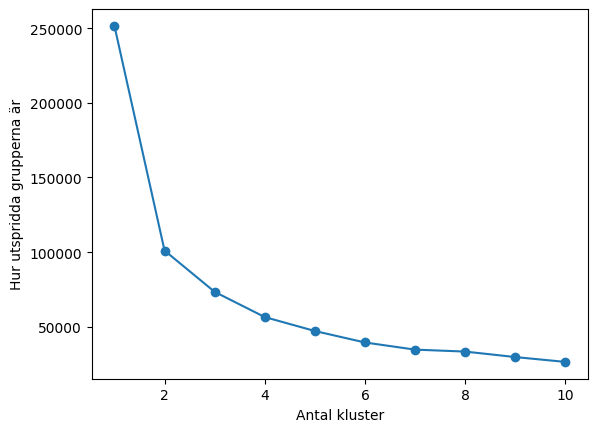

In [13]:
fel = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(X[["median_income", "latitude", "longitude"]])
    fel.append(km.inertia_)

plt.plot(range(1, 11), fel, marker="o")
plt.xlabel("Antal kluster")
plt.ylabel("Hur utspridda grupperna är")
plt.show()

#### 9.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("data/1980sClassics.csv")
print(df.shape)
df.head()

(998, 17)


,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


In [15]:
# Låtarnas ljudegenskaper som vi grupperar på
features = ["Danceability", "Energy", "Loudness", "Acousticness", "Valence", "Tempo"]

# Skala så att t.ex. Tempo (runt 120) inte väger tyngre än Energy (0-1)
X = StandardScaler().fit_transform(df[features])

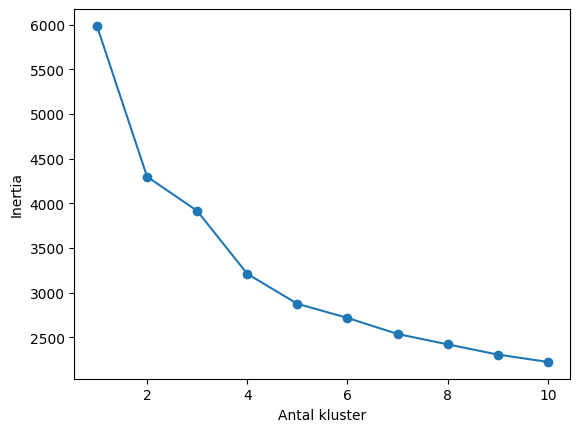

In [16]:
# Armbågsmetoden: leta efter "knäet" där kurvan planar ut
inertia = [KMeans(n_clusters=k, random_state=42).fit(X).inertia_ for k in range(1, 11)]

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Antal kluster")
plt.ylabel("Inertia")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

# Medelvärden per kluster visar vad som utmärker varje grupp
print(df["Cluster"].value_counts().sort_index())
df.groupby("Cluster")[features].mean().round(2)

Cluster
0    336
1    210
2    273
3    179
Name: count, dtype: int64


,Danceability,Energy,Loudness,Acousticness,Valence,Tempo
Cluster,,,,,,
0,0.69,0.80,-6.22,0.14,0.75,115.94
1,0.49,0.72,-6.89,0.17,0.45,143.48
2,0.73,0.56,-11.29,0.19,0.74,114.28
3,0.52,0.35,-12.58,0.61,0.30,113.84


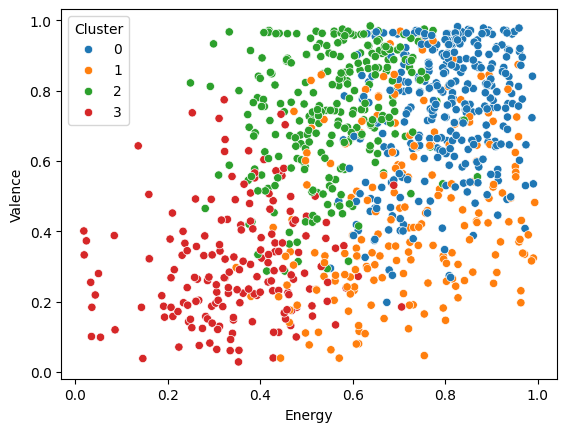

In [18]:
sns.scatterplot(data=df, x="Energy", y="Valence", hue="Cluster", palette="tab10")
plt.show()

In [19]:
# Några exempellåtar från varje kluster
for c in range(4):
    print(f"\nKluster {c}")
    print(df[df["Cluster"] == c][["Track", "Artist"]].sample(5, random_state=42).to_string(index=False))


Kluster 0
                                  Track             Artist
You Should Hear How She Talks About You Melissa Manchester
                          Der Kommissar     After the Fire
                             Rocket 2 U           The Jets
             (KEEP Feeling) Fascination       Human League
                    Tell It To My Heart       Taylor Dayne

Kluster 1
                     Track                 Artist
            The Night Owls      Little River Band
               Cherry Bomb John Cougar Mellencamp
              Cruel Summer             Bananarama
             All This Time                Tiffany
Total Eclipse Of The Heart           Bonnie Tyler

Kluster 2
                      Track          Artist
             Hot Rod Hearts   Robbie Dupree
Wake Me Up Before You Go-Go           Wham!
            Harden My Heart    Quarterflash
            Just To See Her Smokey Robinson
                Rock Steady    The Whispers

Kluster 3
                 Track                